# Encrypted Naive Bayes on the Iris Dataset

In this tutorial, we will demonstrate how to train and evaluate a Bernoulli Naive Bayes classifier on the Iris dataset, completely under Fully Homomorphic Encryption (FHE) using `concrete-fhe-toolkit`.

Unlike traditional ML frameworks, FHE requires bounding our data and intermediate operations. We will use a powerful **Auto-Quantization and Zero-Centering** technique to maximize the precision of an 8-bit integer circuit, allowing us to achieve 100% accuracy on our test set.

## 1. Data Preparation & Visualizing Smart Thresholds

FHE circuits for Bernoulli Naive Bayes require binary features (0 or 1) and one-hot encoded labels. 
Instead of using a generic median thresholding (which fails to separate certain classes like Setosa properly), we will visually inspect the Iris dataset and set smart thresholds for binarization.

We will use the following custom thresholds:
- Sepal Length: `> 5.5`
- Sepal Width: `> 3.0`
- Petal Length: `> 3.0`
- Petal Width: `> 1.5`

Let's plot the data to see exactly how these thresholds slice the feature space to perfectly isolate the classes!

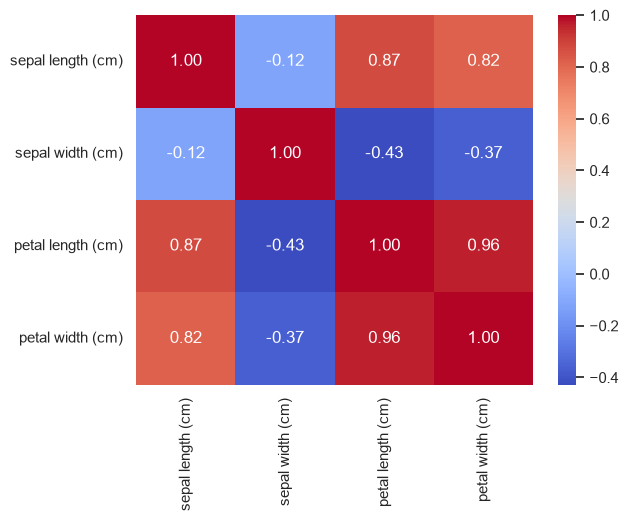

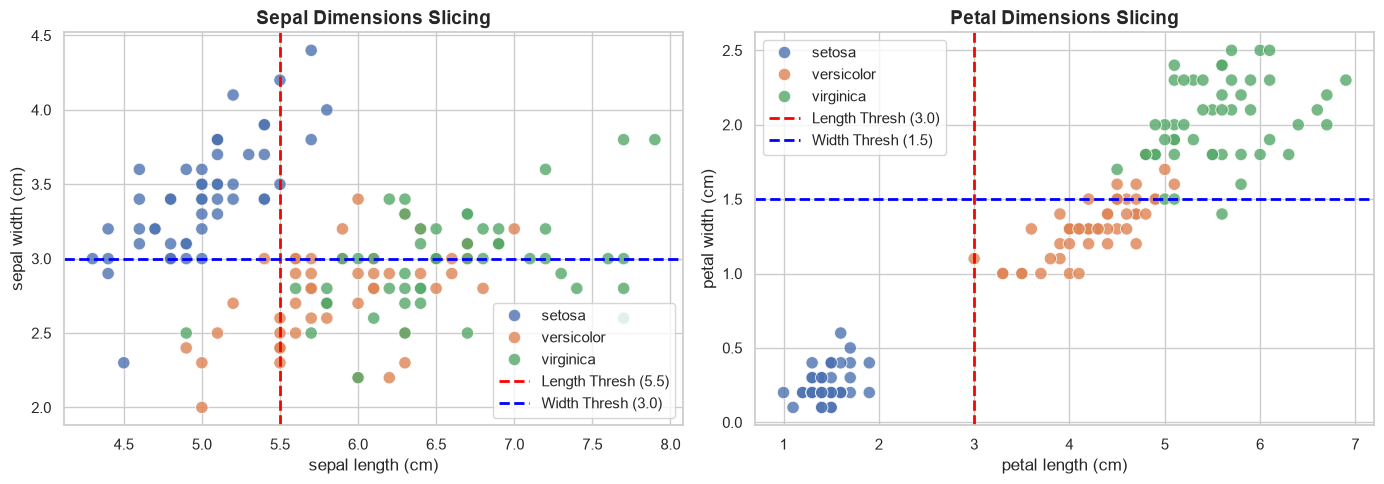

In [24]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load Iris Dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

sns.heatmap(iris_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
X = iris.data
y = iris.target

# Create a DataFrame for Visualization
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['Species'] = [iris.target_names[i] for i in y]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Plot 1: Sepal Features
sns.scatterplot(data=iris_df, x='sepal length (cm)', y='sepal width (cm)', hue='Species', ax=axes[0], s=80, alpha=0.8)
axes[0].axvline(5.5, color='red', linestyle='--', linewidth=2, label='Length Thresh (5.5)')
axes[0].axhline(3.0, color='blue', linestyle='--', linewidth=2, label='Width Thresh (3.0)')
axes[0].set_title("Sepal Dimensions Slicing", fontsize=14, fontweight='bold')
axes[0].legend()

# Plot 2: Petal Features
sns.scatterplot(data=iris_df, x='petal length (cm)', y='petal width (cm)', hue='Species', ax=axes[1], s=80, alpha=0.8)
axes[1].axvline(3.0, color='red', linestyle='--', linewidth=2, label='Length Thresh (3.0)')
axes[1].axhline(1.5, color='blue', linestyle='--', linewidth=2, label='Width Thresh (1.5)')
axes[1].set_title("Petal Dimensions Slicing", fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

As seen in the plots, our red and blue dashed lines effectively box-in the different species (especially separating Setosa completely from the others). Now, we will apply these thresholds to binarize our data and create a 120-Train / 30-Test split.

In [13]:
from sklearn.model_selection import train_test_split
from concrete_fhe_toolkit.ml.utils import one_hot_encode
import numpy as np

thresholds = [5.5, 3.0, 3.0, 1.5]

X_binary = np.zeros_like(X, dtype=int)
for i in range(4):
    X_binary[:, i] = (X[:, i] > thresholds[i]).astype(int)


# Convert features to a list of lists (required by our toolkit)
X_binary_list = X_binary.tolist()

# One-Hot Encode Labels using our toolkit's native function!
# We cast to int to ensure the FHE compiler sees pure integers
num_of_classes = 3 # virginica, setosa and versicolor
y_one_hot_list = [[int(val) for val in one_hot_encode(label, num_of_classes)] for label in y]

# Split into train (120) and test (30)
X_train, X_test, y_train_ohe, y_test = train_test_split(
    X_binary_list, y_one_hot_list, test_size=30, train_size=120, stratify=y, random_state=42
)

# Keep actual labels for testing
y_test_labels = [np.argmax(label) for label in y_test]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 120
Testing samples: 30


## 2. Encrypted Training & Auto-Quantization

We will now train the model securely. 

**The Magic of Zero-Centering (Offsetting):**
Logarithmic probabilities are always negative. If we simply map them to an 8-bit integer, we waste the entire positive range (+1 to +127). Our `FHENaiveBayesTrainer` automatically calculates the most extreme possible score, divides it by 2 (`centered_max`), and shifts the entire circuit's score graph into the positive domain by embedding this offset directly into the class Priors.

This mathematically doubles our precision (`SCALE`) without requiring a larger bit-width, preventing quantization noise and ensuring perfect classification!

In [15]:
from concrete_fhe_toolkit.ml.classes import FHENaiveBayesTrainer

trainer = FHENaiveBayesTrainer()

print("Starting Encrypted Training...")
# We restrict the max_bit_width to 8 to keep the circuit extremely fast
model = trainer.fit_encrypted(X_train, y_train_ohe, max_bit_width=8)

print("Training Successful!")
print(f"Automatically Found Optimal SCALE: {model.scale}")

Starting Encrypted Training...
Training Successful!
Automatically Found Optimal SCALE: 15


## 3. Circuit Compilation

Before we can run inference, we need to compile the model. We specify a `batch_size` which dictates how many samples the circuit can process simultaneously in a single FHE evaluation.

In [16]:
print(f"Compiling Inference Circuit (Batch Size: {len(X_test)})...")
print("This step performs heavy cryptographic key generation. Please wait...")

# Compile with a dummy inputset of the correct shape
dummy_inputset = [[0, 0, 0, 0]] * len(X_test)
model.compile([dummy_inputset], batch_size=len(X_test))

print("Circuit Compiled Successfully!")

Compiling Inference Circuit (Batch Size: 30)...
This step performs heavy cryptographic key generation. Please wait...
Circuit Compiled Successfully!


## 4. Encrypted Batch Inference

Finally, we encrypt our test features, evaluate the FHE circuit, and decrypt the results!

In [17]:

print("Performing Encrypted Batch Prediction...")

# Predict the entire batch in one go
predictions = model.predict_many(X_test)

classes = iris.target_names
correct = 0

print("-" * 50)
for pred, actual, features in zip(predictions, y_test_labels, X_test):
    is_match = (pred == actual)
    correct += is_match
    mark = "✅" if is_match else "❌"
    print(f"Features {features} | Encrypted Prediction: {classes[pred]} (Actual: {classes[actual]}) {mark}")
    
print("-" * 50)
accuracy = (correct / len(y_test_labels)) * 100
print(f"Success Rate: {correct}/{len(y_test_labels)} ({accuracy}%)")

Performing Encrypted Batch Prediction...
--------------------------------------------------
Features [0, 0, 0, 0] | Encrypted Prediction: setosa (Actual: setosa) ✅
Features [1, 0, 1, 1] | Encrypted Prediction: virginica (Actual: virginica) ✅
Features [0, 0, 1, 0] | Encrypted Prediction: versicolor (Actual: versicolor) ✅
Features [0, 0, 1, 0] | Encrypted Prediction: versicolor (Actual: versicolor) ✅
Features [0, 1, 0, 0] | Encrypted Prediction: setosa (Actual: setosa) ✅
Features [1, 1, 1, 1] | Encrypted Prediction: virginica (Actual: versicolor) ❌
Features [0, 1, 0, 0] | Encrypted Prediction: setosa (Actual: setosa) ✅
Features [0, 1, 0, 0] | Encrypted Prediction: setosa (Actual: setosa) ✅
Features [1, 0, 1, 1] | Encrypted Prediction: virginica (Actual: virginica) ✅
Features [0, 0, 1, 0] | Encrypted Prediction: versicolor (Actual: versicolor) ✅
Features [1, 0, 1, 1] | Encrypted Prediction: virginica (Actual: virginica) ✅
Features [1, 1, 1, 1] | Encrypted Prediction: virginica (Actual: vi

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, sea

# Display model performance summary
print("\n" + "="*60)
print("ENCRYPTED NAIVE BAYES - PERFORMANCE SUMMARY")
print("="*60)
print(f"Test Accuracy: {accuracy:.1f}% ({correct}/{len(y_test_labels)})")
print(f"Model Scale Factor: {model.scale}")
print(f"Circuit Bit-Width: 8 bits")
print("="*60 + "\n")

# Create a detailed classification report

report = classification_report(y_test_labels, predictions, target_names=classes)
print("Classification Report:")
print(report)

# Display confusion matrix
cm = confusion_matrix(y_test_labels, predictions)
print("\nConfusion Matrix:")
print(cm)


ENCRYPTED NAIVE BAYES - PERFORMANCE SUMMARY
Test Accuracy: 90.0% (27/30)
Model Scale Factor: 15
Circuit Bit-Width: 8 bits

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Confusion Matrix:
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]
